<a href="https://colab.research.google.com/github/mwoimwoi/forage-midas/blob/flow/Coursework/CSC3831_Final_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSC3831 Final Assessment - Part I: Data Engineering



In [1]:
# Loading in standard packages for analysis, feel free to add an extra packages you'd like to use here
import random
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
# Loading in the corrupted dataset to be used in analysis and imputation
houses_corrupted = pd.read_csv('https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/CORRUPTED/HOUSES/houses_0.1_MAR.csv', header=0)
# Remove an artifact from the dataset
houses_corrupted.drop(["Unnamed: 0"], axis=1, inplace=True)

Above we've loaded in a corrupted version of a housing dataset. The anomalies need to be dealt with and missing values imputed.

### 1. Data Understanding [7]
- Perform ad hoc EDA to understand and describe what you see in the raw dataset
  - Include graphs, statistics, and written descriptions as appropriate
  - Any extra information about the data you can provide here is useful, think about performing an analysis (ED**A**), what would you find interesting or useful?
- Identify features with missing records, outlier records


In [2]:
houses_corrupted.head()
houses_corrupted.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_house_value  20640 non-null  float64
 1   median_income       18576 non-null  float64
 2   housing_median_age  18576 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          18576 non-null  float64
 6   households          20640 non-null  float64
 7   latitude            20640 non-null  float64
 8   longitude           20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
houses_corrupted.describe()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
count,20640.000000,18576.000000,18576.000000,20640.000000,20640.000000,18576.000000,20640.000000,20640.000000,20640.000000
mean,206855.816909,3.929958,28.324182,2635.763081,537.898014,1488.069283,499.539680,35.631861,-119.569704
std,115395.615874,1.964296,12.584914,2181.615252,421.247906,1170.585810,382.329753,2.135952,2.003532
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000
25%,119600.000000,2.560300,18.000000,1447.750000,295.000000,839.000000,280.000000,33.930000,-121.800000
50%,179700.000000,3.572400,28.000000,2127.000000,435.000000,1227.000000,409.000000,34.260000,-118.490000
75%,264725.000000,4.870050,37.000000,3148.000000,647.000000,1803.000000,605.000000,37.710000,-118.010000
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000


<Axes: >

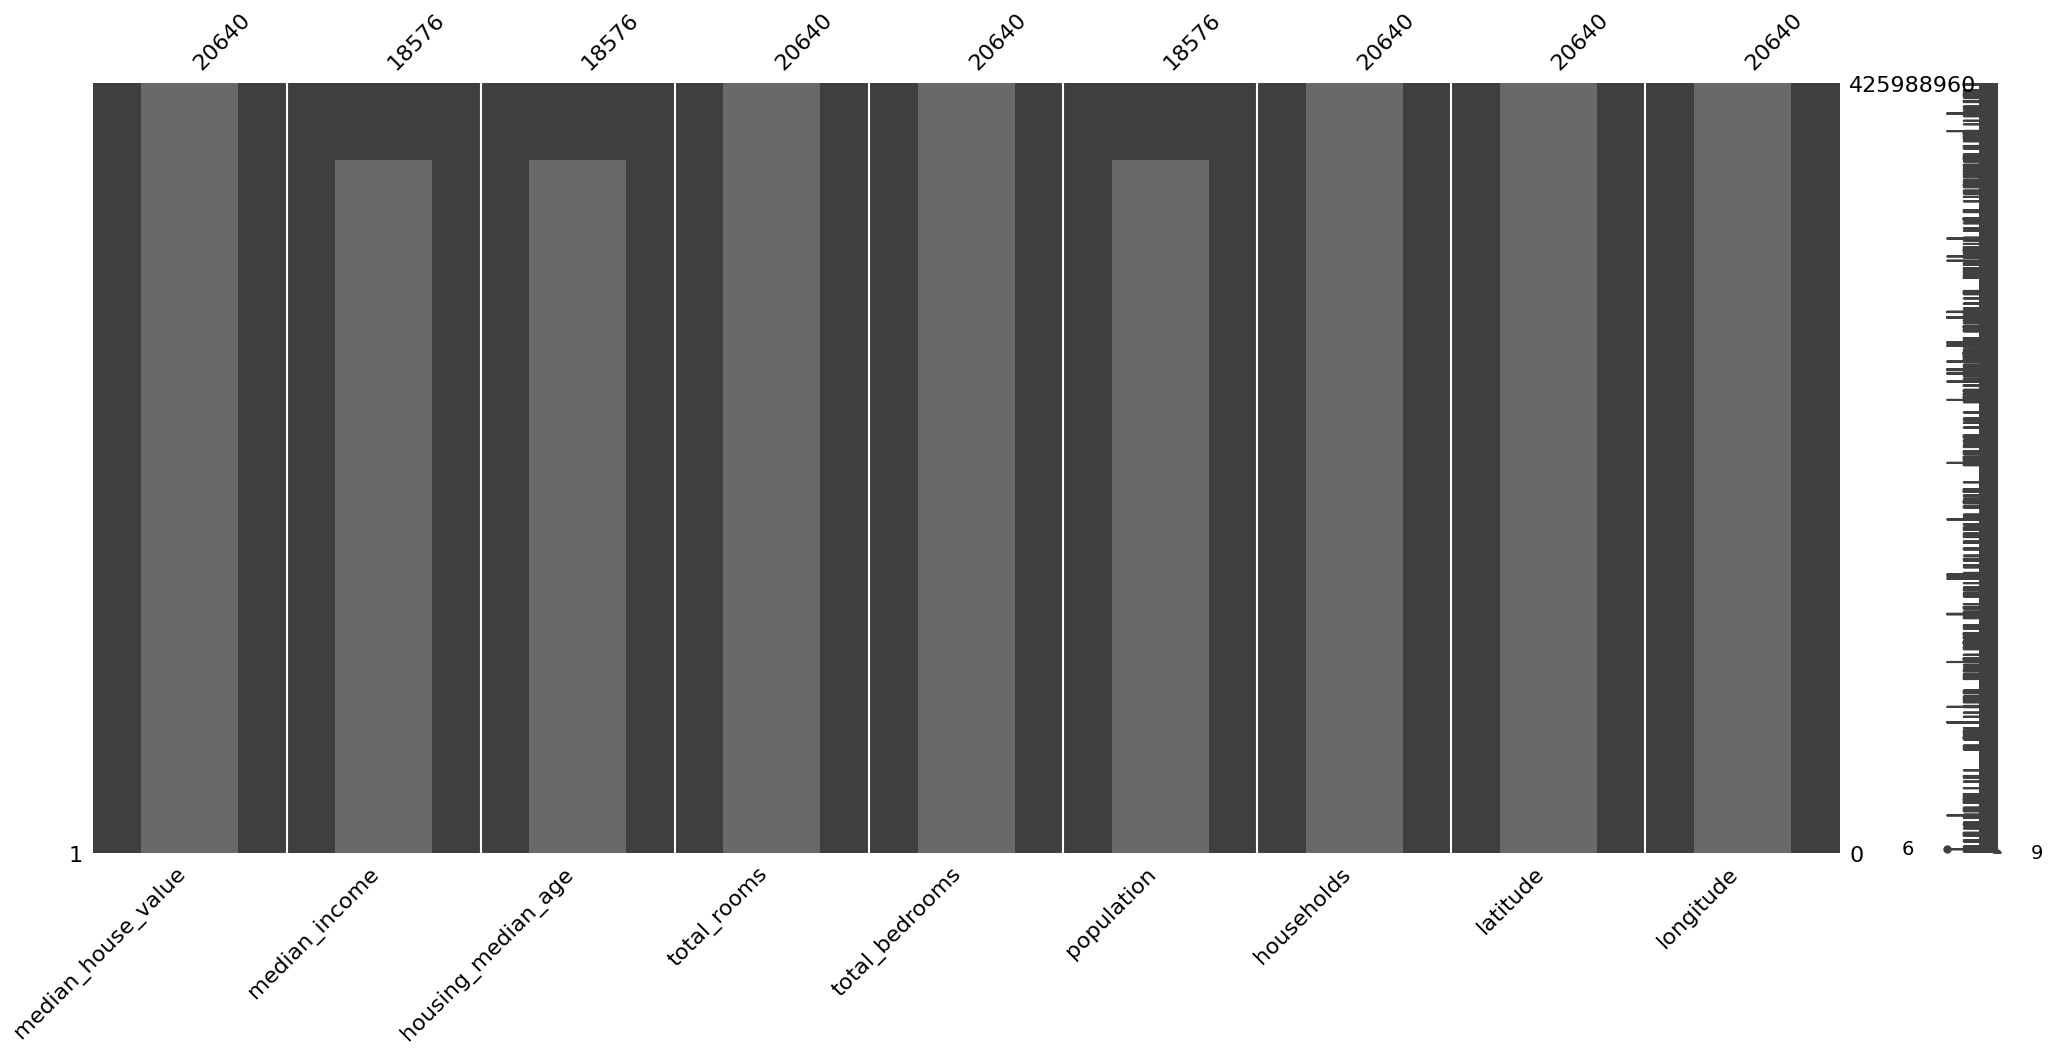

In [4]:
msno.matrix(houses_corrupted)
msno.bar(houses_corrupted)

In [5]:
houses_corrupted.isnull().sum()

,0
median_house_value,0
median_income,2064
housing_median_age,2064
total_rooms,0
total_bedrooms,0
population,2064
households,0
latitude,0
longitude,0


In [6]:
print("\nMissing Values Count:")
missing_values = houses_corrupted.isnull().sum()
display(missing_values[missing_values > 0])


Missing Values Count:


,0
median_income,2064
housing_median_age,2064
population,2064


### Missing Values
- Displayed missing value counts for all features.

- Observed patterns in missing data using visualizations (missingno.matrix and missingno.bar).

- Noted key features with significant missingness.

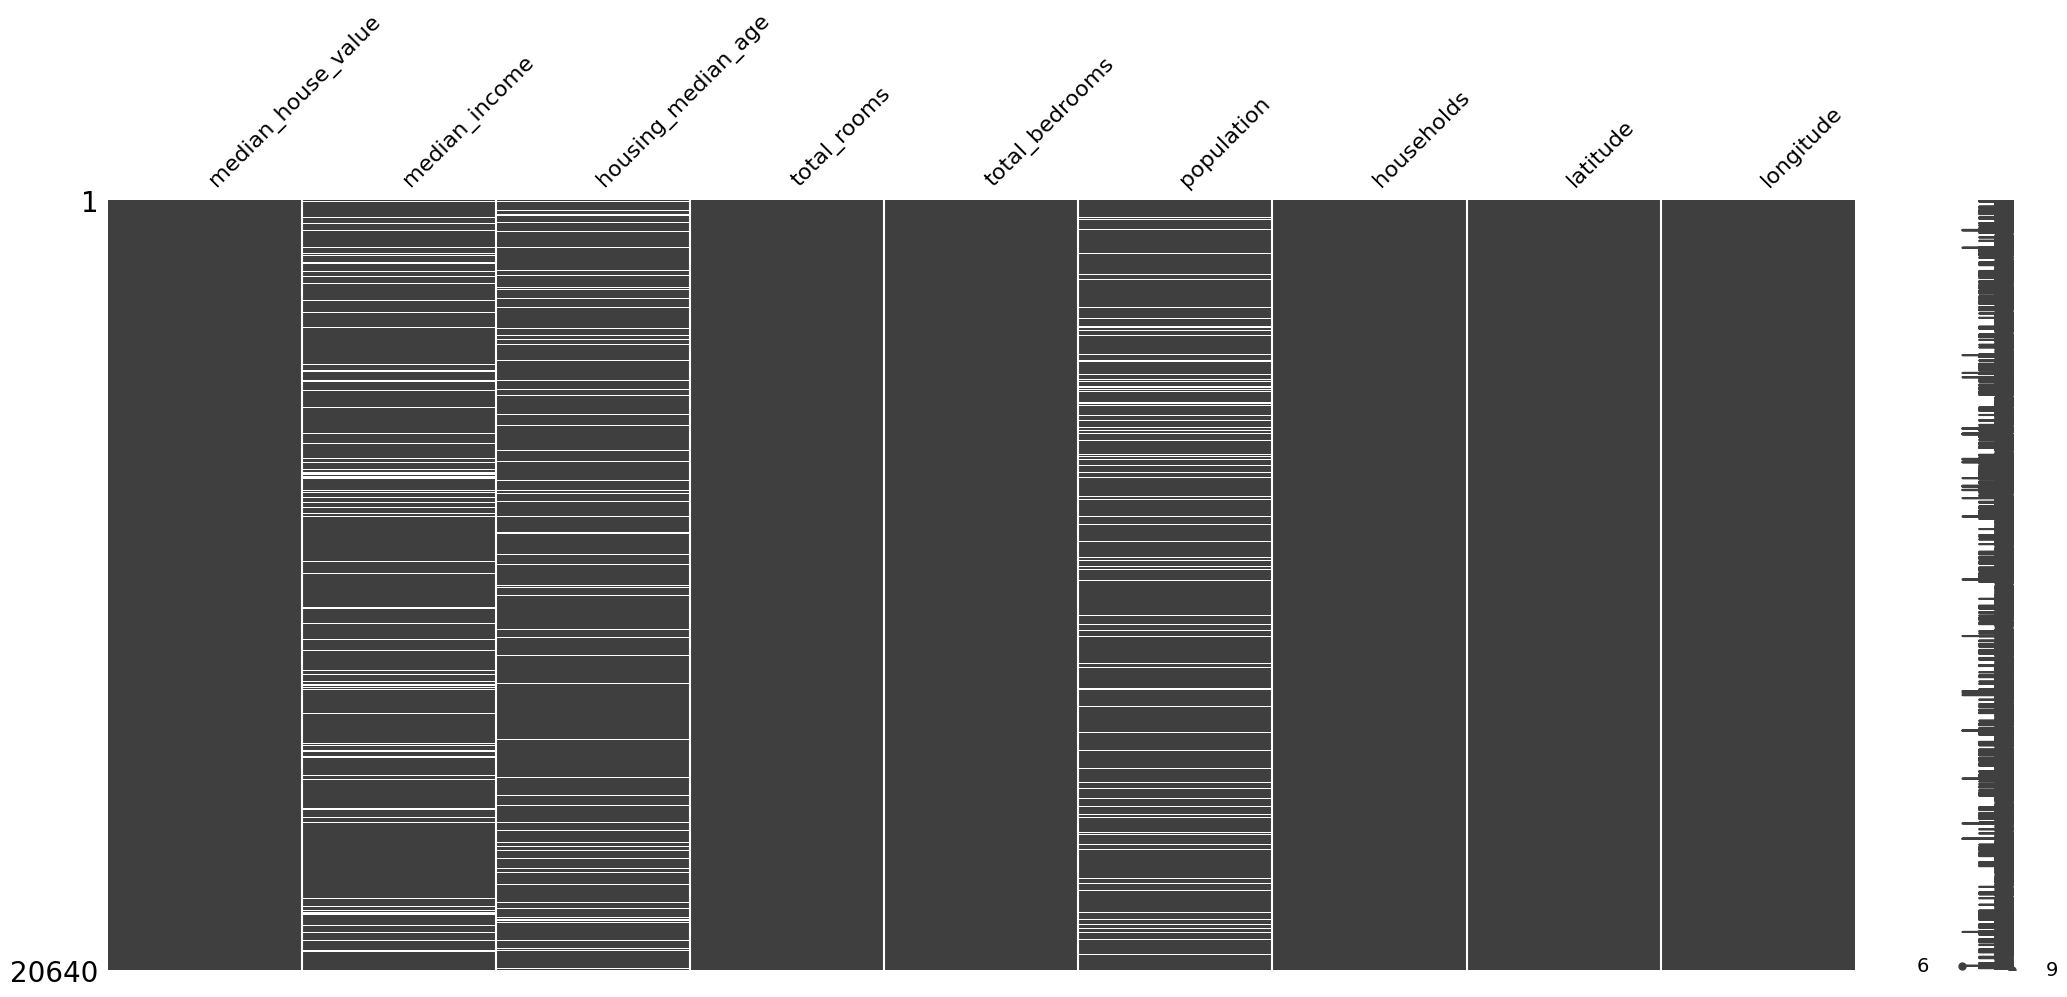

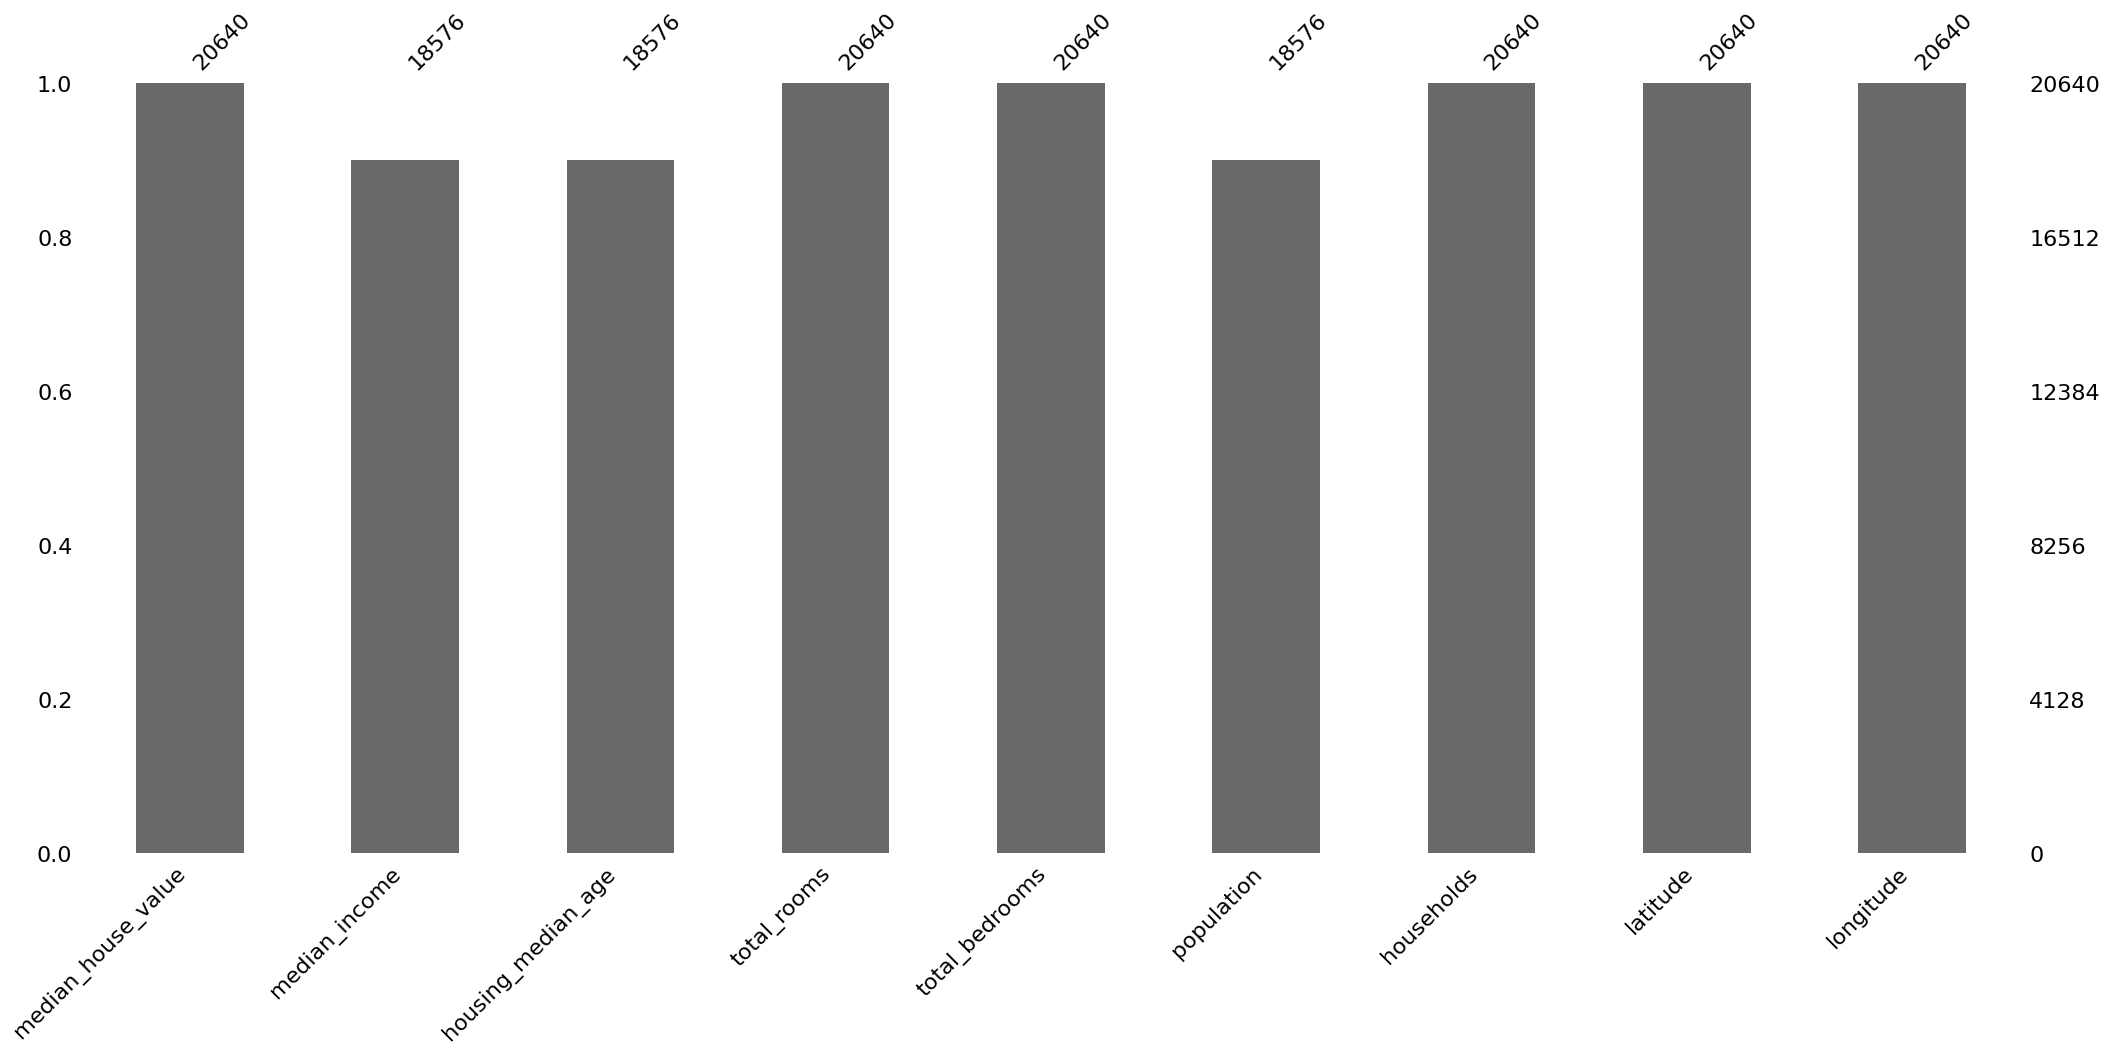

In [7]:
import matplotlib.pyplot as plt
msno.matrix(houses_corrupted)
plt.show()

msno.bar(houses_corrupted)
plt.show()


Detecting Outliers Using Boxplots:


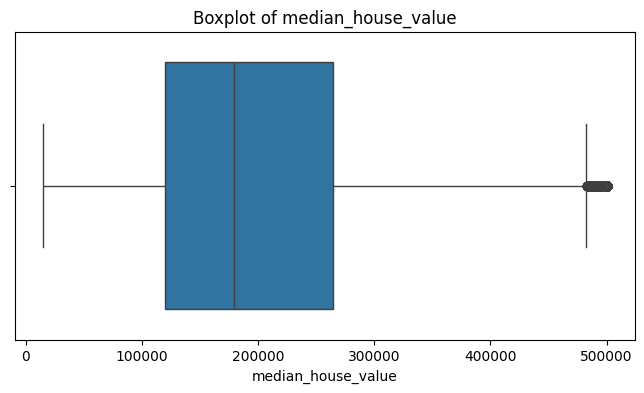

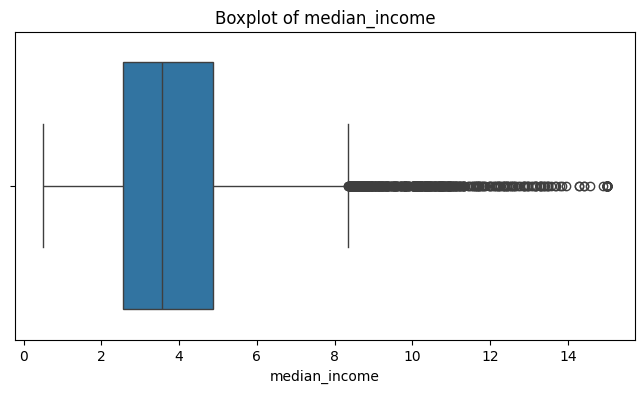

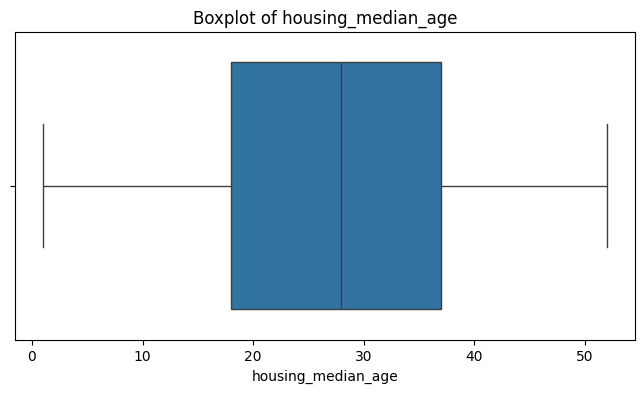

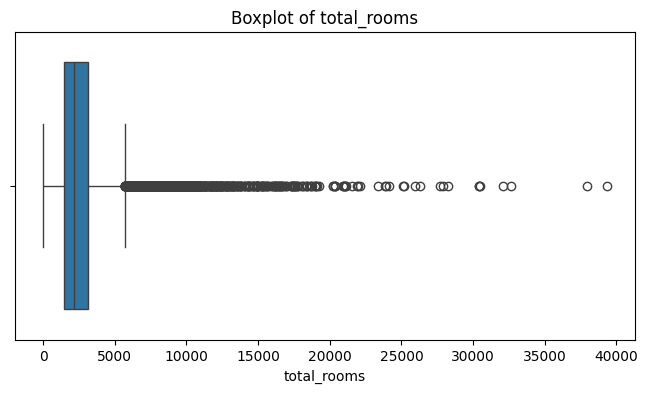

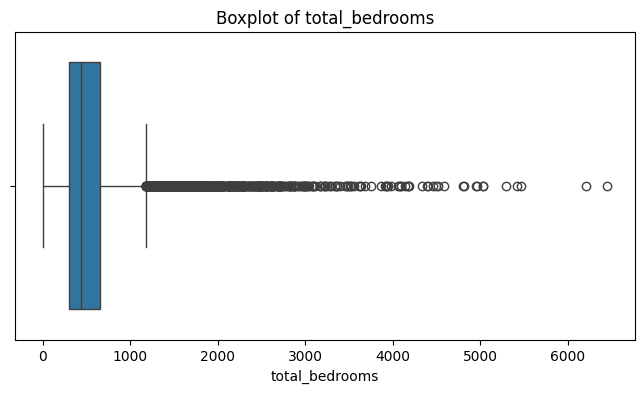

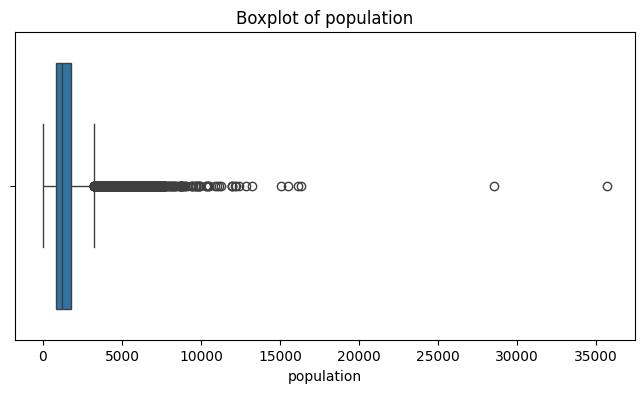

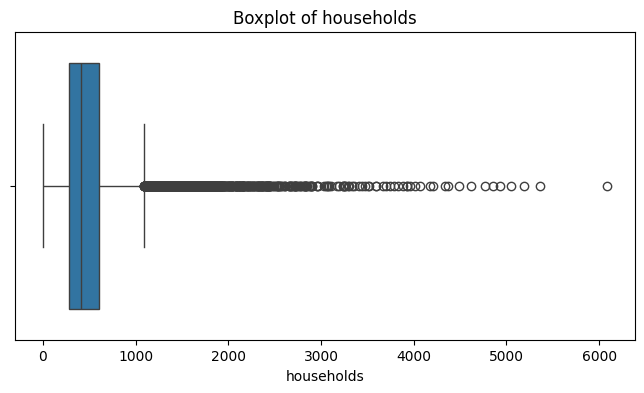

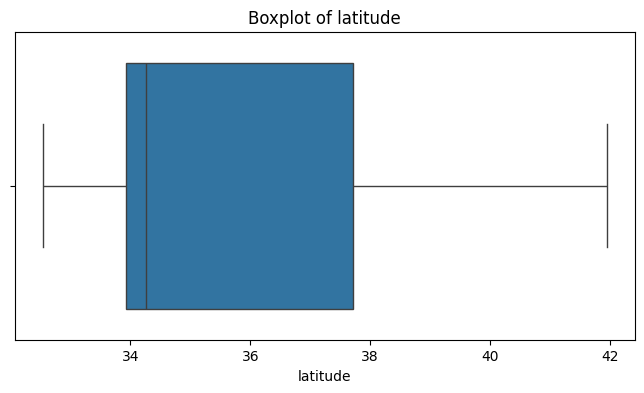

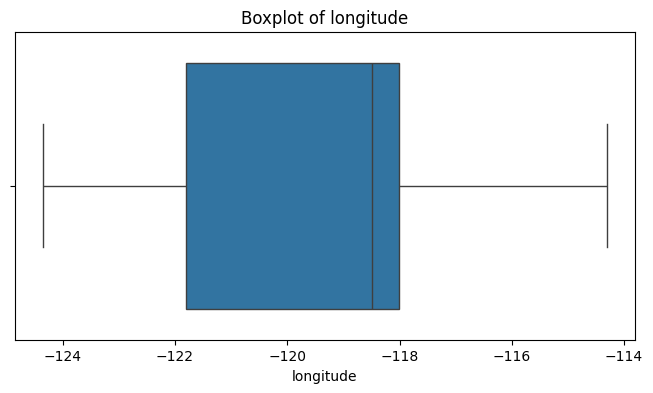

In [8]:
print("\nDetecting Outliers Using Boxplots:")

numeric_columns = houses_corrupted.select_dtypes(include=['float64', 'int64']).columns
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=houses_corrupted[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

### Outliers
- Used boxplots to identify outliers for numerical features.
- Highlighted features with a large spread or extreme values.
- Boxplots representing median income, total rooms, total bedrooms, population, and households all have a large spread and several extreme outliers past the upper whisker
- However the latter four boxplots have a larger spread than median income
- Boxplot representing median house value is the only other one with outliers as well, but there are less and the spread is much smaller
- Boxplots of housing median age, latitude and longitude have no outliers at all


Feature Distributions:


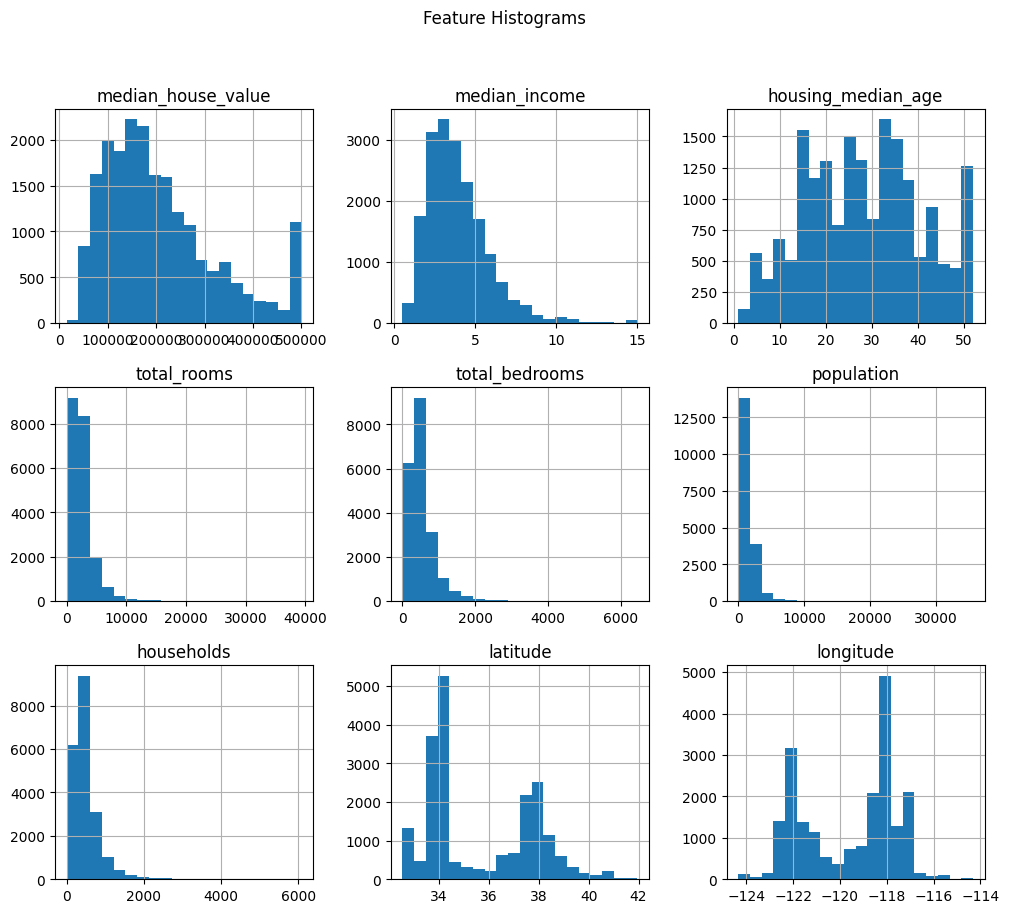

In [9]:
# Distribution of Features
print("\nFeature Distributions:")
houses_corrupted.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Histograms")
plt.show()

### Feature Distributions
- Generated histograms for numerical columns to examine their distributions.
- Commented on skewness, normality, or multimodal patterns in features.
- Positively skewed histograms include: median income, total room, total bedrooms, population
- None seem to display any normal distribution
- Latitude and longitude show non-symmetric bimodal distribution


Correlation Matrix:


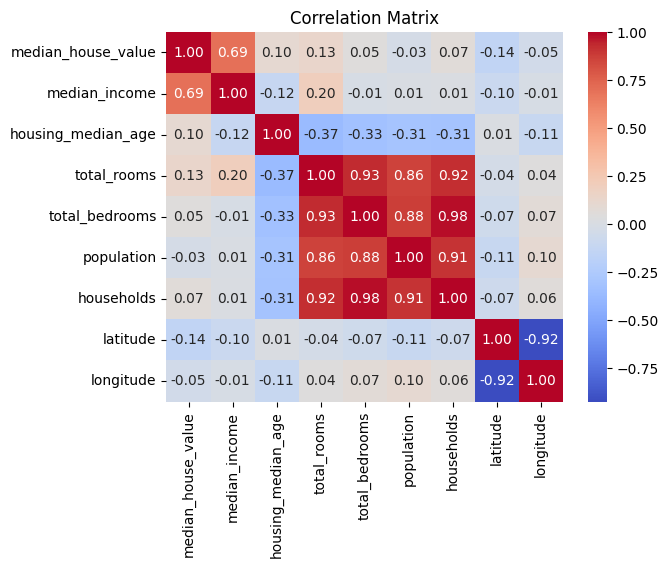

In [10]:
# Correlation Analysis
print("\nCorrelation Matrix:")
correlation_matrix = houses_corrupted.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis
- Presented a correlation heatmap to identify relationships between numerical features.
- Highlighted highly correlated features that may require further investigation.
- Moderately high correlation: Median income & median house value (0.69)
- Strong positive correlation: total rooms, total bedrooms, & population all have correlation with each other (ranging from 0.88 to 0.98)
- Strong negative correlation: latitude & longitude (-0.92)

In [11]:
# Additional Exploratory Graphs (if categorical features are present)
categorical_columns = houses_corrupted.select_dtypes(include=['object']).columns
if len(categorical_columns) > 0:
    print("\nCategorical Feature Value Counts:")
    for column in categorical_columns:
        print(f"\nValue Counts for {column}:")
        display(houses_corrupted[column].value_counts())

        # Visualize Categorical Distributions
        sns.countplot(y=houses_corrupted[column])
        plt.title(f"Distribution of {column}")
        plt.show()
else:
    print("No categorical features detected.")

No categorical features detected.


### 2. Outlier Identification [10]
- Utilise a statistical outlier detection approach (i.e., **no** KNN, LOF, 1Class SVM)
- Utilise an algorithmic outlier detection method of your choice
- Compare results and decide what to do with identified outleirs
  - Include graphs, statistics, and written descriptions as appropriate
- Explain what you are doing, and why your analysis is appropriate
- Comment on benefits/detriments of statistical and algorithmic outlier detection approaches


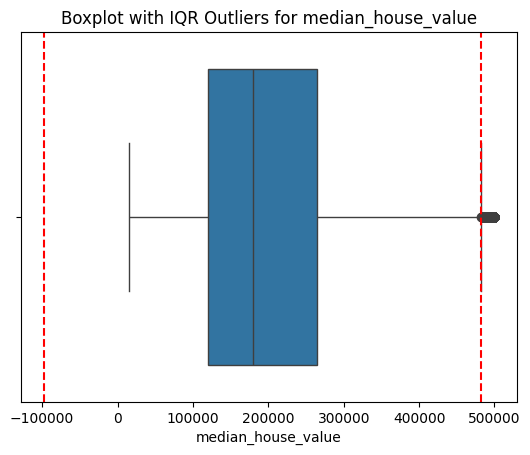

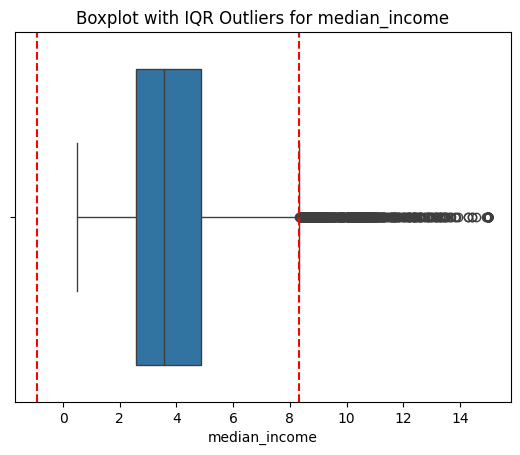

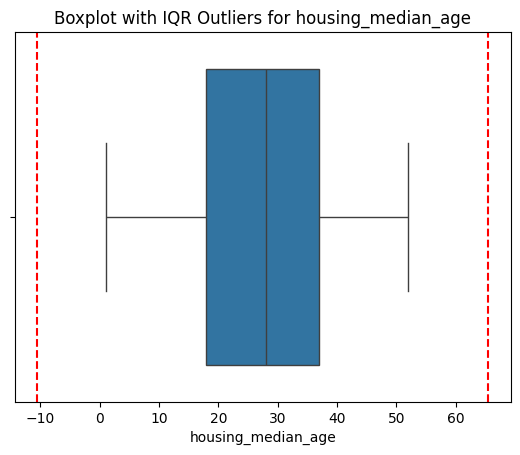

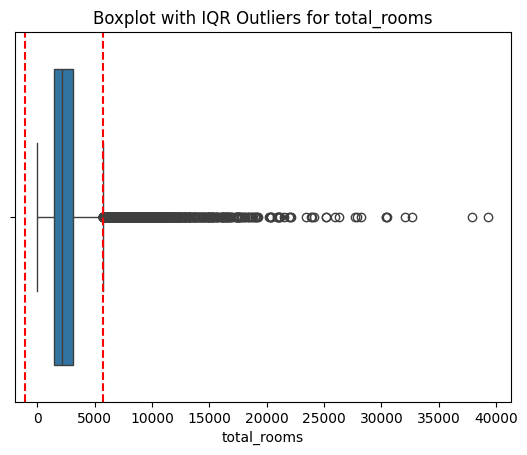

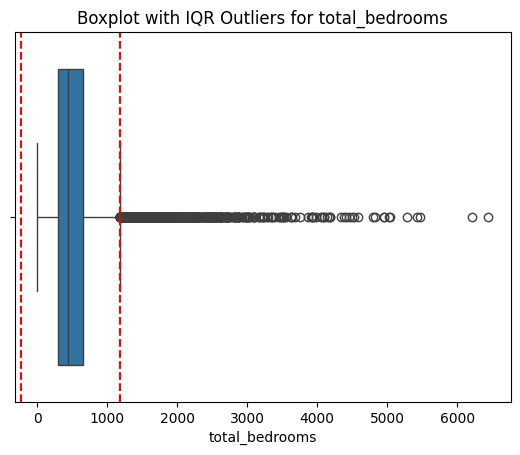

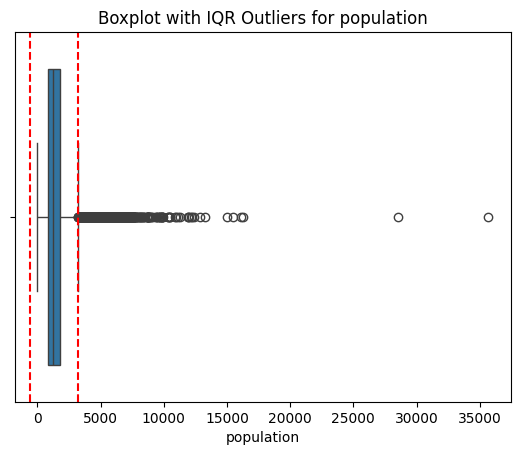

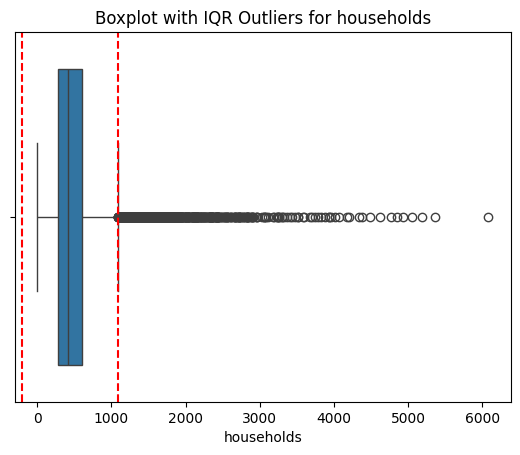

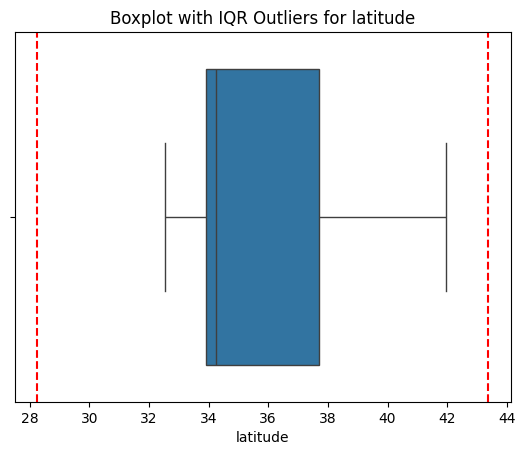

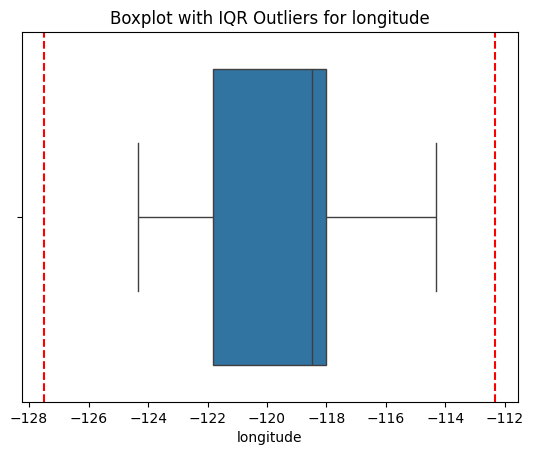

median_house_value: 1071 outliers
median_income: 562 outliers
housing_median_age: 0 outliers
total_rooms: 1287 outliers
total_bedrooms: 1282 outliers
population: 1077 outliers
households: 1220 outliers
latitude: 0 outliers
longitude: 0 outliers


In [12]:
# Statistical Outlier Detection
outliers_statistical = {}

for column in numeric_columns:
    Q1 = houses_corrupted[column].quantile(0.25)
    Q3 = houses_corrupted[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = houses_corrupted[(houses_corrupted[column] < lower_bound) | (houses_corrupted[column] > upper_bound)]
    outliers_statistical[column] = outliers

    # Visualize Outliers
    sns.boxplot(x=houses_corrupted[column])
    plt.axvline(lower_bound, color='red', linestyle='--')
    plt.axvline(upper_bound, color='red', linestyle='--')
    plt.title(f"Boxplot with IQR Outliers for {column}")
    plt.show()

# Count of outliers per feature
for column, outliers in outliers_statistical.items():
    print(f"{column}: {len(outliers)} outliers")

In [1]:
from sklearn.ensemble import IsolationForest

# Initialize the model
isolation_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

# Fit Isolation Forest only on non-missing data
non_missing_data = houses_corrupted[numeric_columns].dropna()
isolation_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
isolation_forest.fit(non_missing_data)

# Predict anomalies for non-missing rows
outlier_predictions = isolation_forest.predict(non_missing_data)

# Create a new column, default to NaN
houses_corrupted['IsolationForest_Outlier'] = np.nan

# Assign predictions to rows without missing values
houses_corrupted.loc[non_missing_data.index, 'IsolationForest_Outlier'] = outlier_predictions

# Count of outliers
print(f"Isolation Forest detected {sum(houses_corrupted['IsolationForest_Outlier'] == -1)} outliers")

NameError: name 'houses_corrupted' is not defined

### 3. Imputation [10]
- Identify which features should be imputed and which should be removed
  - Provide a written rationale for this decision
- Impute the missing records using KNN imputation
- Impute the missing records using MICE imputation
- Compare both imputed datasets feature distributions against each other and the non-imputed data
- Build a regressor on all thre datasets
  - Use regression models to predict house median price
  - Compare regressors of non-imputed data against imputed datas
  - **Note**: If you're struggling to compare against the original dataset focus on comparing the two imputed datasets against each other


In [ ]:
# Use this dataset for comparison against the imputed datasets
houses = pd.read_csv('https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/ORIGINAL/houses.csv', header=0)

### 4. Conclusions & Throughts [3]
- Disucss methods used for anomaly detection, pros/cons of each method
- Disucss challenges/difficulties in anomaly detection implementation
- Discuss methods used for imputation, pros/cons of each method
- Discuss challenges/difficulties in imputation implementation